In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
try:
  df = pd.read_excel('merged.xlsx')
  display(df.head())
except Exception as e:
      print(f"An error occurred during download: {e}")

,Unnamed: 0,interview_id,birth_year,birth_year_source,year_left_country,leave_year_source,year_of_arrival,arrival_year_source,year_of_arrival_inferred,years_in_transit,...,narrator_name,interviewer_name,date,location,interview_length,sub-collection,narrator_initials,interviewer_initials,narrator_dialogue,interviewer_dialogue
0,0,VAHF0001,1949.0,regex,NaN,NaN,1979.0,regex,0,NaN,...,Hồ Văn Khởi,Nancy Bùi,"May 25, 2010","San Jose, California",00:50:51,Vietnamese American Heritage Foundation 500 Or...,HVK,NB,"I’m Hồ Văn Khởi. I was born in Gò Công, Việt N...",Hello Sir! Would you please introduce your nam...
1,1,VAHF0002,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,...,Charlie Van Le,Pham Quang Tuan,"November 5, 2010","Westminster, California",00:12:13,Vietnamese American Heritage Foundation 500 Or...,CVL,PQT,"Right now, I just graduated from the Universit...",I’d like to ask you if you can state your name...
2,2,VAHF0003,1970.0,regex,1979.0,regex,1979.0,regex,0,0.0,...,Huỳnh Văn Chỉnh (Aka Trung Chỉnh),Darlena Tran,"November 07, 2010","Westminster, California Length of Interview: 0...",NaN,Vietnamese American Heritage Foundation 500 Or...,HVC,DT,"My name is Huynh Van Chinh, I have been perfor...",What is your name? Where were you born? How is...
3,3,VAHF0005,1984.0,regex,NaN,NaN,1975.0,regex,0,NaN,...,Tiffany Le,Roger Le,"November 10, 2010","Westminster, California",01:05:18,Vietnamese American Heritage Foundation 500 Or...,TL,RL,My name is Tiffany Le. I was born in Riverside...,"Hi, name is Roger Le and today is November 10,..."
4,4,VAHF0006,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,...,Roger Minh Le,Tuan Quang Pham,"November 5, 2010","Westminster, California",00:17:49,Vietnamese American Heritage Foundation 500 Or...,RL,PQT,"My name’s Roger Minh Le, I’m 24, and I current...",My name is Tuan Quang Pham and today’s day is ...


In [ ]:
# remove the values with missing interviews
filtered_df = df.copy()

# Convert relevant columns to string type and replace empty strings/whitespace with NaN
for col in ['interviewer_dialogue', 'narrator_dialogue']:
    filtered_df[col] = filtered_df[col].astype(str).replace(r'^\s*$', np.nan, regex=True)
    filtered_df[col] = filtered_df[col].astype(str).replace('nan', np.nan) #Replacing excel string "nan" to numpy NaN

# Drop rows where 'interviewer_dialogue' or 'narrator_dialogue' are NaN
filtered_df = filtered_df.dropna(subset=['interviewer_dialogue', 'narrator_dialogue'])

# Display the first few rows of the filtered DataFrame
display(filtered_df)

,Unnamed: 0,interview_id,birth_year,birth_year_source,year_left_country,leave_year_source,year_of_arrival,arrival_year_source,year_of_arrival_inferred,years_in_transit,...,narrator_name,interviewer_name,date,location,interview_length,sub-collection,narrator_initials,interviewer_initials,narrator_dialogue,interviewer_dialogue
0,0,VAHF0001,1949.0,regex,NaN,NaN,1979.0,regex,0,NaN,...,Hồ Văn Khởi,Nancy Bùi,"May 25, 2010","San Jose, California",00:50:51,Vietnamese American Heritage Foundation 500 Or...,HVK,NB,"I’m Hồ Văn Khởi. I was born in Gò Công, Việt N...",Hello Sir! Would you please introduce your nam...
1,1,VAHF0002,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,...,Charlie Van Le,Pham Quang Tuan,"November 5, 2010","Westminster, California",00:12:13,Vietnamese American Heritage Foundation 500 Or...,CVL,PQT,"Right now, I just graduated from the Universit...",I’d like to ask you if you can state your name...
2,2,VAHF0003,1970.0,regex,1979.0,regex,1979.0,regex,0,0.0,...,Huỳnh Văn Chỉnh (Aka Trung Chỉnh),Darlena Tran,"November 07, 2010","Westminster, California Length of Interview: 0...",NaN,Vietnamese American Heritage Foundation 500 Or...,HVC,DT,"My name is Huynh Van Chinh, I have been perfor...",What is your name? Where were you born? How is...
3,3,VAHF0005,1984.0,regex,NaN,NaN,1975.0,regex,0,NaN,...,Tiffany Le,Roger Le,"November 10, 2010","Westminster, California",01:05:18,Vietnamese American Heritage Foundation 500 Or...,TL,RL,My name is Tiffany Le. I was born in Riverside...,"Hi, name is Roger Le and today is November 10,..."
4,4,VAHF0006,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,...,Roger Minh Le,Tuan Quang Pham,"November 5, 2010","Westminster, California",00:17:49,Vietnamese American Heritage Foundation 500 Or...,RL,PQT,"My name’s Roger Minh Le, I’m 24, and I current...",My name is Tuan Quang Pham and today’s day is ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,184,VAOHP0374,1989.0,life_map,NaN,NaN,1991.0,life_map,1,NaN,...,Naomi Ngoc Yen Quach,Jessica Thi Phan,"February 18, 2019","Westminster, California",NaN,"Vietnamese American Experience Course, Winter ...",NNYQ,JTP,"I was born in San Jose, CA but I moved down to...",This is Jessica Phan with VietStories: Vietnam...
185,185,VAOHP0375,1991.0,regex,1978.0,life_map,1993.0,life_map,1,15.0,...,Sang Nguyen (Steven Thanh Nguyen),Sharmaine Santiago,"February 20, 2019","Santa Ana, California",NaN,Vietnamese American Experience Class Oral Hist...,STN,SS,"Hi Sharmine. I’m doing well, thank you for ask...",This is Sharmaine Santiago with VietStories: V...
187,187,VAOHP0378,1965.0,regex,1977.0,regex,1984.0,regex,0,7.0,...,Lâm Lệ Thanh,Isabelle Tâm Nhã Trần,"February 4, 2019","Orange, California",NaN,Vietnamese American Experience Class Oral Hist...,TL,IT,"Hi, my name is Thanh Lam. T-H-A-N-H. Last name...",Can you state and spell your name? Can you spe...
189,189,VAOHP0380,1975.0,regex,1980.0,regex,1981.0,life_map,1,1.0,...,Tran Ngoc Tu,Hanh Truong,"February 08, 2019","Garden Grove, California",01:17:14,"Vietnamese American Experience Course, Winter ...",TT,HT,"Ok. Before 1975, [I] lived very normally. Had ...",This is Hanh Truong with VietStories: Vietname...


In [ ]:
df_waves = filtered_df.dropna(subset=['wave'])
display(df_waves[['wave', 'narrator_dialogue']])

,wave,narrator_dialogue
0,Wave 2 (1979),"I’m Hồ Văn Khởi. I was born in Gò Công, Việt N..."
1,Wave 3 (ODP-era),"Right now, I just graduated from the Universit..."
2,Wave 2 (1979),"My name is Huynh Van Chinh, I have been perfor..."
3,Wave 1 (1975),My name is Tiffany Le. I was born in Riverside...
4,Wave 1 (1975),"My name’s Roger Minh Le, I’m 24, and I current..."
...,...,...
184,Wave 3 (ODP-era),"I was born in San Jose, CA but I moved down to..."
185,Wave 3 (ODP-era),"Hi Sharmine. I’m doing well, thank you for ask..."
187,Wave 3 (ODP-era),"Hi, my name is Thanh Lam. T-H-A-N-H. Last name..."
189,Wave 2 (1979),"Ok. Before 1975, [I] lived very normally. Had ..."


In [ ]:
df_waves['wave'] = df_waves['wave'].apply(lambda x: int(x[5]))
display(df_waves[['wave', 'narrator_dialogue']])

/tmp/ipykernel_132/582676248.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_waves['wave'] = df_waves['wave'].apply(lambda x: int(x[5]))


,wave,narrator_dialogue
0,2,"I’m Hồ Văn Khởi. I was born in Gò Công, Việt N..."
1,3,"Right now, I just graduated from the Universit..."
2,2,"My name is Huynh Van Chinh, I have been perfor..."
3,1,My name is Tiffany Le. I was born in Riverside...
4,1,"My name’s Roger Minh Le, I’m 24, and I current..."
...,...,...
184,3,"I was born in San Jose, CA but I moved down to..."
185,3,"Hi Sharmine. I’m doing well, thank you for ask..."
187,3,"Hi, my name is Thanh Lam. T-H-A-N-H. Last name..."
189,2,"Ok. Before 1975, [I] lived very normally. Had ..."


In [ ]:
!pip install gensim

import string
import gensim
from gensim.corpora import Dictionary

In [ ]:
translator = str.maketrans('', '', string.punctuation)
dataset = list(df_waves["narrator_dialogue"].apply(lambda a: a.translate(translator).lower().split()))
dct = Dictionary(dataset)
print(dct)
corpus = [dct.doc2bow(line) for line in dataset]
df_waves['bow'] = corpus


def fill_vector(bow):
  new = np.zeros(len(dct), dtype=int)
  for token_id, count in bow:
    new[token_id] = count
  return new

df_waves['bow_with_missing'] = df_waves['bow'].apply(fill_vector)
display(df_waves[['wave', 'narrator_dialogue', 'bow', 'bow_with_missing']])

Dictionary<16006 unique tokens: ['1', '10', '100s', '12', '12th']...>


/tmp/ipykernel_132/2203346344.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_waves['bow'] = corpus
/tmp/ipykernel_132/2203346344.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_waves['bow_with_missing'] = df_waves['bow'].apply(fill_vector)


,wave,narrator_dialogue,bow,bow_with_missing
0,2,"I’m Hồ Văn Khởi. I was born in Gò Công, Việt N...","[(0, 3), (1, 3), (2, 1), (3, 3), (4, 1), (5, 1...","[3, 3, 1, 3, 1, 1, 1, 3, 1, 1, 1, 1, 4, 2, 1, ..."
1,3,"Right now, I just graduated from the Universit...","[(22, 1), (30, 27), (31, 2), (32, 5), (42, 9),...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,2,"My name is Huynh Van Chinh, I have been perfor...","[(0, 2), (1, 11), (3, 1), (7, 1), (8, 4), (9, ...","[2, 11, 0, 1, 0, 0, 0, 1, 4, 1, 0, 1, 9, 1, 0,..."
3,1,My name is Tiffany Le. I was born in Riverside...,"[(10, 1), (12, 1), (14, 1), (16, 8), (19, 2), ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, ..."
4,1,"My name’s Roger Minh Le, I’m 24, and I current...","[(0, 1), (19, 1), (23, 1), (30, 34), (31, 1), ...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...
184,3,"I was born in San Jose, CA but I moved down to...","[(0, 2), (12, 1), (16, 2), (27, 1), (30, 173),...","[2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
185,3,"Hi Sharmine. I’m doing well, thank you for ask...","[(12, 3), (16, 1), (21, 2), (27, 3), (30, 83),...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, ..."
187,3,"Hi, my name is Thanh Lam. T-H-A-N-H. Last name...","[(0, 1), (1, 2), (8, 1), (10, 2), (18, 1), (25...","[1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, ..."
189,2,"Ok. Before 1975, [I] lived very normally. Had ...","[(0, 7), (1, 2), (8, 1), (9, 1), (12, 7), (16,...","[7, 2, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 7, 0, 0, ..."


In [ ]:
import torch

In [ ]:
dict_waves = {
    1: [1,0,0],
    2: [0,1,0],
    3: [0,0,1]
    }
def vectorize_wave(wave_num):
  wave_vector = dict_waves[wave_num]
  return wave_vector

df_waves['wave_vector'] = df_waves['wave'].apply(vectorize_wave)
output_tensor = torch.Tensor(df_waves['wave_vector'])
print(output_tensor)

tensor([[0., 1., 0.],
        [0., 0., 1.],
        [0., 1., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 0., 1.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [1., 0., 0.],
        [0., 0., 1.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0

/tmp/ipykernel_132/1120929390.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_waves['wave_vector'] = df_waves['wave'].apply(vectorize_wave)


In [ ]:
input_tensor = torch.Tensor(df_waves['bow_with_missing'])
print(input_tensor)

tensor([[ 3.,  3.,  1.,  ...,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
        [ 2., 11.,  0.,  ...,  0.,  0.,  0.],
        ...,
        [ 1.,  2.,  0.,  ...,  0.,  0.,  0.],
        [ 7.,  2.,  0.,  ...,  1.,  1.,  1.],
        [ 0.,  0.,  0.,  ...,  0.,  0.,  0.]])


In [ ]:
from torch import nn

In [ ]:
model = torch.nn.Sequential(
    nn.Linear(in_features=input_tensor.shape[1], out_features=8192, bias=True),
    nn.Sigmoid(),
    nn.Linear(in_features=8192, out_features=4096, bias=True),
    nn.Dropout(0.2),
    nn.Linear(in_features=4096, out_features=2048, bias=True),
    nn.Dropout(0.2),
    nn.Linear(in_features=2048, out_features=1024, bias=True),
    nn.Sigmoid(),
    nn.Linear(in_features=1024, out_features=output_tensor.shape[1], bias=True),
    nn.Softmax(dim=1)
)

print(model)

Sequential(
  (0): Linear(in_features=16006, out_features=8192, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=8192, out_features=4096, bias=True)
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=4096, out_features=2048, bias=True)
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=2048, out_features=1024, bias=True)
  (7): Sigmoid()
  (8): Linear(in_features=1024, out_features=3, bias=True)
  (9): Softmax(dim=1)
)


In [ ]:
compiled_model = torch.compile(model)
print(compiled_model)

OptimizedModule(
  (_orig_mod): Sequential(
    (0): Linear(in_features=16006, out_features=8192, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=8192, out_features=4096, bias=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=4096, out_features=2048, bias=True)
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=2048, out_features=1024, bias=True)
    (7): Sigmoid()
    (8): Linear(in_features=1024, out_features=3, bias=True)
    (9): Softmax(dim=1)
  )
)


In [ ]:
dummy_input = torch.randn(10, len(dct))
dummy_output = compiled_model(dummy_input)
print(dummy_output)

tensor([[0.3345, 0.4030, 0.2625],
        [0.3302, 0.4072, 0.2625],
        [0.3355, 0.4007, 0.2638],
        [0.3329, 0.4021, 0.2649],
        [0.3372, 0.4013, 0.2616],
        [0.3375, 0.3994, 0.2631],
        [0.3383, 0.4034, 0.2583],
        [0.3313, 0.4082, 0.2604],
        [0.3364, 0.4032, 0.2604],
        [0.3339, 0.4008, 0.2653]], grad_fn=<CompiledFunctionBackward>)


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(input_tensor, output_tensor, test_size=0.2)

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(compiled_model.parameters(), lr=1e-4) # Reduced learning rate to stabilize training

train_dataset = TensorDataset(X_train, Y_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [ ]:
loss_df = pd.DataFrame(columns=("epoch", "avg_train_loss", "test_loss"))

In [ ]:
def train(dataloader, model, loss_fn, optimizer):
  model.train()
  losses = []
  for batch, (X, Y) in enumerate(dataloader):
    pred = compiled_model(X)
    loss = loss_fn(pred, Y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
  return sum(losses) / len(losses)

In [ ]:
epochs = 10
for t in range(epochs):
  print("Epoch", t+1)
  avg_train_loss = train(train_dataloader, compiled_model, loss_fn, optimizer)

  compiled_model.eval()
  pred = compiled_model(X_test)
  loss = loss_fn(pred, Y_test)
  test_loss = loss.item()

  loss_row = pd.DataFrame({"epoch": [t+1], "avg_train_loss": [avg_train_loss], "test_loss": [test_loss]})
  loss_df = pd.concat([loss_df, loss_row], ignore_index=True)

Epoch 1


/tmp/ipykernel_132/3536943298.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  loss_df = pd.concat([loss_df, loss_row], ignore_index=True)


Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10


In [ ]:
display(loss_df)

,epoch,avg_train_loss,test_loss
0,1,0.233418,0.210479
1,2,0.226375,0.232927
2,3,0.231480,0.221069
3,4,0.212266,0.218864
4,5,0.199416,0.215416
5,6,0.184988,0.209912
6,7,0.160633,0.206020
7,8,0.133548,0.205860
8,9,0.100754,0.203471
9,10,0.071009,0.231054


<Axes: xlabel='epoch', ylabel='loss'>

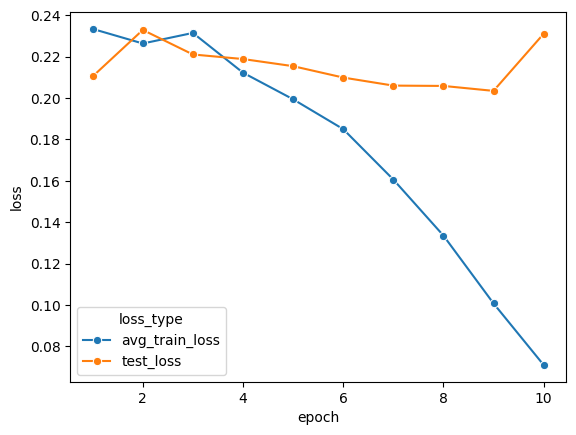

In [ ]:
df_melted = loss_df.melt(id_vars=['epoch'], var_name='loss_type', value_name='loss')
sns.lineplot(data=df_melted, x='epoch', y='loss', hue='loss_type', marker='o')

In [ ]:
pred = compiled_model(X_test)
loss = nn.L1Loss()
loss = loss(pred, Y_test)
print("Test Loss:", loss)

Test Loss: tensor(0.4280, grad_fn=<MeanBackward0>)
